In [72]:

%pip install -q torch --index-url https://download.pytorch.org/whl/cpu
%pip install -q transformers requests networkx matplotlib ipywidgets


In [73]:
REPO_URL = "https://github.com/psf/requests"   # any public GitHub repo URL

MODEL_NAME = "google/flan-t5-small"   #for 300mb

MAX_NEW_TOKENS = 300
SKIP_AI_SUMMARY = True    # True = just do the structural analysis, no model load at all


In [74]:
# --- Imports ------------------------------------------
import getpass
import json
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

In [75]:
import requests
from IPython.display import display, Markdown, HTML, FileLink

IGNORE_DIRS = {
    ".git", "node_modules", "__pycache__", "venv", ".venv", "env",
    "dist", "build", ".next", ".idea", ".vscode", ".mypy_cache",
    ".pytest_cache", "coverage", ".tox", "target", "vendor", ".turbo",
}

CODE_EXTENSIONS = {
    # Python
    ".py": "python",

    # JavaScript
    ".js": "javascript",
    ".jsx": "javascript",
    ".mjs": "javascript",
    ".cjs": "javascript",

    # TypeScript
    ".ts": "typescript",
    ".tsx": "typescript",

    # Web
    ".html": "html",
    ".htm": "html",
    ".xhtml": "html",

    ".css": "css",
    ".scss": "scss",
    ".sass": "sass",
    ".less": "less",

    # Templates
    ".vue": "vue",
    ".svelte": "svelte",
    ".astro": "astro",

    # Data / Config
    ".json": "json",
    ".json5": "json",
    ".yaml": "yaml",
    ".yml": "yaml",
    ".toml": "toml",
    ".xml": "xml",

    # Markdown
    ".md": "markdown",
    ".mdx": "mdx",

    # Shell
    ".sh": "bash",
    ".bash": "bash",
    ".zsh": "zsh",
    ".ps1": "powershell",
    ".bat": "batch",
    ".cmd": "batch",

    # Languages
    ".java": "java",
    ".go": "go",
    ".rb": "ruby",
    ".rs": "rust",
    ".php": "php",
    ".c": "c",
    ".h": "c",
    ".cpp": "cpp",
    ".cc": "cpp",
    ".cxx": "cpp",
    ".hpp": "cpp",
    ".hh": "cpp",
    ".cs": "csharp",
    ".kt": "kotlin",
    ".swift": "swift",
    ".scala": "scala",
    ".r": "r",
    ".sql": "sql",
    ".lua": "lua",
    ".dart": "dart",
    ".ex": "elixir",
    ".exs": "elixir",
    ".erl": "erlang",
    ".fs": "fsharp",
    ".jl": "julia",
    ".pl": "perl",
    ".m": "objective-c",
    ".mm": "objective-c++",

    # Docker / Infrastructure
    ".dockerfile": "dockerfile",
    ".tf": "terraform",
    ".tfvars": "terraform",

    # Notebooks
    ".ipynb": "jupyter",
}

print("Constants loaded.")


Constants loaded.


In [76]:
MAX_FILE_BYTES = 2_000_000   # no more than this
MAX_FILES = 2000

LANG_COLORS = {
    "python": "#5eead4", "javascript": "#f5d423", "typescript": "#5b9cf5",
    "java": "#e88b4b", "go": "#4bd0e8", "ruby": "#e8556e", "rust": "#e8813f",
    "php": "#9a7de8", "c": "#8ba3b5", "cpp": "#8ba3b5", "csharp": "#a15be8",
    "kotlin": "#c98be8", "swift": "#e8724b", "unknown": "#9aa5ad",
}

print("Language colors loaded.")


Language colors loaded.


In [77]:
# --- Cloning & file discovery -------------------------------------------
import io
import zipfile
import re as _re


def _parse_owner_repo(repo_url: str):
    """Extract owner, repo from a GitHub URL"""

    cleaned = repo_url.strip().rstrip("/")
    cleaned = _re.sub(r"\.git$", "", cleaned)
    m = _re.search(r"github\.com[:/]+([^/]+)/([^/]+)$", cleaned)
    if not m:
        raise ValueError(f"Could not parse an owner/repo from URL: {repo_url}")
    return m.group(1), m.group(2)


def _download_repo_zip(repo_url: str, dest_dir: str) -> str:
    """Download a repo as a zip"""

    owner, repo = _parse_owner_repo(repo_url)
    last_error = None
    for branch in ("main", "master"):
        zip_url = f"https://github.com/{owner}/{repo}/archive/refs/heads/{branch}.zip"
        try:
            resp = requests.get(zip_url, timeout=60)
        except Exception as e:
            last_error = str(e)
            continue
        if resp.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
                zf.extractall(dest_dir)

            # GitHub zips extract into a single
            extracted = [p for p in Path(dest_dir).iterdir() if p.is_dir()]
            if len(extracted) == 1:
                inner = extracted[0]
                for item in inner.iterdir():
                    shutil.move(str(item), str(Path(dest_dir) / item.name))
                inner.rmdir()
            return dest_dir
        last_error = f"HTTP {resp.status_code} for branch '{branch}'"
    raise RuntimeError(f"Could not download zip for {owner}/{repo} (tried main/master): {last_error}")


def clone_repo(repo_url: str, dest_dir: str) -> str:
    """Get a repo into destination_dir"""

    cmd = ["git", "clone", "--depth", "1", repo_url, dest_dir]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        if result.returncode != 0:
            raise RuntimeError(result.stderr.strip() or "git clone failed")
        return dest_dir
    except FileNotFoundError:

        print("git not found on PATH — downloading repo as a zip archive")
        shutil.rmtree(dest_dir, ignore_errors=True)
        Path(dest_dir).mkdir(parents=True, exist_ok=True)
        return _download_repo_zip(repo_url, dest_dir)


def iter_source_files(root: str):
    count = 0
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in IGNORE_DIRS and not d.startswith(".git")]
        for fname in filenames:
            ext = Path(fname).suffix
            if ext not in CODE_EXTENSIONS:
                continue
            full = Path(dirpath) / fname
            try:
                if full.stat().st_size > MAX_FILE_BYTES:
                    continue
            except OSError:
                continue
            count += 1
            if count > MAX_FILES:
                return
            yield full


def read_text(path: Path) -> str:
    try:
        return path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return ""


print("Cloning & discovery functions loaded")


Cloning & discovery functions loaded


In [78]:
# --- Parsing: regex-based---

LANGUAGE_PATTERNS = {
    "python": {
        "imports": [re.compile(r'^\s*import\s+([\w\.]+)', re.M),
                    re.compile(r'^\s*from\s+([\w\.]+)\s+import', re.M)],
        "functions": re.compile(r'^(async\s+)?def\s+(\w+)\s*\(', re.M),
        "classes": re.compile(r'^\s*class\s+(\w+)\s*(?:\(([^)]*)\))?', re.M),
        "entry_names": {"main.py", "cli.py", "manage.py", "__main__.py", "app.py", "run.py"},
        "entry_patterns": [r'if\s+__name__\s*==\s*[\'"]__main__[\'"]',
                            r'\bargparse\.ArgumentParser\b', r'\bclick\.command\b', r'@click\.'],
    },
    "javascript": {
        "imports": [re.compile(r'''(?:import\s+(?:[\w*{}\s,]+\s+from\s+)?|require\()\s*['"]([^'"]+)['"]''')],
        "functions": re.compile(r'(?:export\s+)?(?:default\s+)?(?:async\s+)?function\s+(\w+)\s*\('),
        "classes": re.compile(r'(?:export\s+)?(?:default\s+)?class\s+(\w+)(?:\s+extends\s+([\w.]+))?'),
        "entry_names": {"index.js", "index.ts", "main.js", "main.ts", "server.js", "server.ts", "app.js", "cli.js"},
        "entry_patterns": [r'^#!/usr/bin/env node'],
        "extra_functions": re.compile(r'(?:export\s+)?const\s+(\w+)\s*=\s*(?:async\s*)?\([^)]*\)?\s*=>'),
    },
    "java": {
        "imports": [re.compile(r'^\s*import\s+([\w\.]+);', re.M)],
        "functions": re.compile(r'(?:public|private|protected|static|\s)+[\w<>\[\]]+\s+(\w+)\s*\([^;{]*\)\s*\{'),
        "classes": re.compile(r'(?:public\s+|private\s+)?(?:abstract\s+)?class\s+(\w+)(?:\s+extends\s+(\w+))?'),
        "entry_names": set(),
        "entry_patterns": [r'public\s+static\s+void\s+main\s*\('],
    },
    "csharp": {
        "imports": [re.compile(r'^\s*using\s+([\w\.]+);', re.M)],
        "functions": re.compile(r'(?:public|private|protected|static|\s)+[\w<>\[\]]+\s+(\w+)\s*\([^;{]*\)\s*\{'),
        "classes": re.compile(r'(?:public\s+|private\s+)?(?:abstract\s+)?class\s+(\w+)(?:\s*:\s*(\w+))?'),
        "entry_names": set(),
        "entry_patterns": [r'static\s+void\s+Main\s*\(', r'static\s+\w+\s+Main\s*\('],
    },
    "go": {
        "imports": [re.compile(r'^\s*import\s+"([^"]+)"', re.M), re.compile(r'^\s*"([^"]+)"', re.M)],
        "functions": re.compile(r'^\s*func\s+(?:\([^)]*\)\s*)?(\w+)\s*\(', re.M),
        "classes": re.compile(r'^\s*type\s+(\w+)\s+struct', re.M),
        "entry_names": {"main.go"},
        "entry_patterns": [r'^\s*func\s+main\s*\(', r'^\s*package\s+main'],
    },
    "ruby": {
        "imports": [re.compile(r'^\s*require(?:_relative)?\s+[\'"]([^\'"]+)[\'"]', re.M)],
        "functions": re.compile(r'^\s*def\s+(\w+)', re.M),
        "classes": re.compile(r'^\s*class\s+(\w+)(?:\s*<\s*(\w+))?', re.M),
        "entry_names": set(),
        "entry_patterns": [r'if\s+__FILE__\s*==\s*\$0'],
    },
    "rust": {
        "imports": [re.compile(r'^\s*use\s+([\w:]+)', re.M)],
        "functions": re.compile(r'^\s*(?:pub\s+)?(?:async\s+)?fn\s+(\w+)', re.M),
        "classes": re.compile(r'^\s*(?:pub\s+)?struct\s+(\w+)', re.M),
        "entry_names": {"main.rs"},
        "entry_patterns": [r'^\s*fn\s+main\s*\('],
    },
    "php": {
        "imports": [re.compile(r'^\s*use\s+([\w\\]+);', re.M)],
        "functions": re.compile(r'^\s*(?:public\s+|private\s+|static\s+)*function\s+(\w+)\s*\(', re.M),
        "classes": re.compile(r'^\s*class\s+(\w+)(?:\s+extends\s+(\w+))?', re.M),
        "entry_names": {"index.php"},
        "entry_patterns": [],
    },
}
LANGUAGE_PATTERNS["typescript"] = LANGUAGE_PATTERNS["javascript"]

# very rough generic fallback for c/cpp/kotlin/swift — best-effort only
GENERIC_PATTERN = {
    "imports": [re.compile(r'^\s*#include\s*[<"]([^">]+)[">]', re.M),
                re.compile(r'^\s*import\s+([\w\.]+)', re.M)],
    "functions": re.compile(r'^\s*(?:[\w:\<\>\[\]\*&]+\s+)+(\w+)\s*\([^;{]*\)\s*\{', re.M),
    "classes": re.compile(r'^\s*(?:public\s+|private\s+)?class\s+(\w+)', re.M),
    "entry_names": {"main.c", "main.cpp"},
    "entry_patterns": [r'\bint\s+main\s*\(', r'\bfunc\s+main\s*\('],
}


def parse_source(path: Path, root: Path, language: str) -> dict:
    src = read_text(path)
    rel = path.relative_to(root).as_posix()
    patterns = LANGUAGE_PATTERNS.get(language, GENERIC_PATTERN)

    imports = []
    for pat in patterns["imports"]:
        for m in pat.finditer(src):
            imports.append({"module": m.group(1), "type": "import"})

    functions = []
    for m in patterns["functions"].finditer(src):
        name = m.group(m.lastindex) if m.lastindex else m.group(0)
        is_async = bool(re.search(r'\basync\b', m.group(0)))
        functions.append({"name": name, "line": None, "async": is_async})
    if "extra_functions" in patterns:
        for m in patterns["extra_functions"].finditer(src):
            functions.append({"name": m.group(1), "line": None, "async": "async" in m.group(0)})

    classes = []
    for m in patterns["classes"].finditer(src):
        groups = m.groups()
        name = groups[0]
        base = groups[1] if len(groups) > 1 and groups[1] else None
        classes.append({"name": name, "bases": [base] if base else [], "line": None, "methods": []})

    is_entry = path.name in patterns.get("entry_names", set())
    reasons = [f"conventional entry filename ({path.name})"] if is_entry else []
    for pat_str in patterns.get("entry_patterns", []):
        if re.search(pat_str, src, re.M):
            is_entry = True
            reasons.append(f"matched pattern: {pat_str}")

    return {
        "path": rel, "language": language, "imports": imports, "classes": classes,
        "functions": functions, "is_entry_point": is_entry, "entry_point_reasons": reasons,
        "loc": (src.count("\n") + 1) if src else 0,
    }


def parse_file(path: Path, root: Path) -> dict:
    lang = CODE_EXTENSIONS.get(path.suffix, "unknown")
    return parse_source(path, root, lang)


print("Regex-based multi-language parser loaded (no ast module used).")


Regex-based multi-language parser loaded (no ast module used).


In [79]:
# --- File tree -----------------------------------------------------------

def build_file_tree(root: str, files_data: list) -> dict:
    tree = {"name": Path(root).name, "type": "dir", "children": {}}
    for f in files_data:
        parts = Path(f["path"]).parts
        node = tree
        for i, part in enumerate(parts):
            if i == len(parts) - 1:
                node["children"].setdefault(part, {
                    "name": part, "type": "file", "language": f["language"],
                    "is_entry_point": f["is_entry_point"], "loc": f["loc"], "path": f["path"],
                })
            else:
                node = node["children"].setdefault(part, {"name": part, "type": "dir", "children": {}})
    return _tree_to_list(tree)


def _tree_to_list(node: dict) -> dict:
    if node["type"] == "file":
        return node
    children = [_tree_to_list(c) for c in node["children"].values()]
    children.sort(key=lambda n: (n["type"] != "dir", n["name"].lower()))
    return {"name": node["name"], "type": "dir", "children": children}


def print_file_tree(node, prefix=""):
    """Pretty-print the tree with box-drawing characters, directly in the notebook."""
    if node["type"] == "file":
        marker = " ●" if node.get("is_entry_point") else ""
        print(f"{prefix}{node['name']}{marker}  ({node.get('loc', 0)} loc)")
        return
    print(f"{prefix}{node['name']}/")
    children = node.get("children", [])
    for i, child in enumerate(children):
        connector = "└── " if i == len(children) - 1 else "├── "
        extension = "    " if i == len(children) - 1 else "│   "
        _print_tree_child(child, prefix + connector, prefix + extension)


def _print_tree_child(node, line_prefix, child_prefix):
    if node["type"] == "file":
        marker = " ●" if node.get("is_entry_point") else ""
        print(f"{line_prefix}{node['name']}{marker}")
        return
    print(f"{line_prefix}{node['name']}/")
    children = node.get("children", [])
    for i, child in enumerate(children):
        connector = "└── " if i == len(children) - 1 else "├── "
        extension = "    " if i == len(children) - 1 else "│   "
        _print_tree_child(child, child_prefix + connector, child_prefix + extension)


print("File tree builder + printer loaded.")


File tree builder + printer loaded.


In [80]:
# --- Relationship / module map -------------------------------------------

def build_module_map(files_data: list) -> list:
    """Resolve imports to in-repo files where possible; otherwise mark external"""

    stem_index = {}
    for f in files_data:
        stem_index.setdefault(Path(f["path"]).stem, []).append(f["path"])

    edges = []
    for f in files_data:
        src_path = f["path"]
        for imp in f["imports"]:
            mod = imp["module"]
            if not mod:
                continue
            target = None
            clean = mod.lstrip(".")
            segments = re.split(r"[./\\:]+", clean)
            candidate_stem = segments[-1] if segments and segments[-1] else None
            if candidate_stem and candidate_stem in stem_index:
                candidates = stem_index[candidate_stem]
                target = min(candidates, key=lambda p: abs(len(Path(p).parts) - len(Path(src_path).parts)))

            if target and target != src_path:
                edges.append({"from": src_path, "to": target, "module": mod, "external": False})
            elif not mod.startswith("."):
                edges.append({"from": src_path, "to": None, "module": mod, "external": True})
    return edges


print("Module map builder loaded.")


Module map builder loaded.


In [81]:
# --- Top-level orchestration ----------------------------------------------

def summarize_repo(root: str) -> dict:
    root_path = Path(root)
    files_data = []
    for f in iter_source_files(root):
        try:
            files_data.append(parse_file(f, root_path))
        except Exception as e:
            files_data.append({
                "path": f.relative_to(root_path).as_posix(), "language": "unknown",
                "imports": [], "classes": [], "functions": [], "is_entry_point": False,
                "entry_point_reasons": [], "loc": 0, "error": str(e),
            })

    tree = build_file_tree(root, files_data)
    edges = build_module_map(files_data)
    entry_points = [f for f in files_data if f["is_entry_point"]]

    lang_counts = {}
    for f in files_data:
        lang_counts[f["language"]] = lang_counts.get(f["language"], 0) + 1

    stats = {
        "total_files": len(files_data),
        "total_loc": sum(f["loc"] for f in files_data),
        "languages": lang_counts,
        "total_classes": sum(len(f["classes"]) for f in files_data),
        "total_functions": sum(len(f["functions"]) for f in files_data),
        "internal_edges": len([e for e in edges if not e.get("external")]),
        "external_deps": sorted({e["module"] for e in edges if e.get("external")}),
    }

    return {
        "repo_name": Path(root).name,
        "file_tree": tree,
        "files": files_data,
        "edges": edges,
        "entry_points": entry_points,
        "stats": stats,
    }


print("summarize_repo() ready.")


summarize_repo() ready.


In [82]:
# --- AI summary-----------------

def condense_for_local_model(summary: dict, max_files: int = 8) -> dict:
    files = summary["files"]

    def score(f):
        return (
            len(f.get("classes", [])) * 3
            + len(f.get("functions", [])) * 2
            + len(f.get("imports", []))
            + (10 if f.get("is_entry_point") else 0)
        )

    ranked = sorted(files, key=score, reverse=True)[:max_files]

    key_files = []
    for f in ranked:
        classes = [c["name"] for c in f.get("classes", [])][:3]
        functions = [fn["name"] for fn in f.get("functions", [])][:4]
        key_files.append(f"{f['path']} ({f['language']}): classes={classes}, functions={functions}")

    return {
        "repo_name": summary["repo_name"],
        "stats_line": (
            f"{summary['stats']['total_files']} files, {summary['stats']['total_loc']} lines, "
            f"languages: {summary['stats']['languages']}"
        ),
        "entry_points": [f["path"] for f in summary["entry_points"]][:5],
        "key_files_lines": key_files,
        "external_deps": summary["stats"]["external_deps"][:10],
    }


def build_local_prompt(condensed: dict) -> str:
    files_block = "\n".join(f"- {line}" for line in condensed["key_files_lines"])
    entry_block = ", ".join(condensed["entry_points"]) or "none detected"
    deps_block = ", ".join(condensed["external_deps"]) or "none detected"
    return (
        f"Summarize "
        f"Repository: {condensed['repo_name']}. Stats: {condensed['stats_line']}. "
        f"Entry points: {entry_block}. Key files and what they define:\n{files_block}\n"
        f"External dependencies: {deps_block}.\n"
        f"Write 3-5 sentences covering: what the project likely does, its main "
        f"language/stack, how the key files relate, and how to run it."
    )


print("Condensation + prompt builder loaded.")


Condensation + prompt builder loaded.


In [83]:
# --- AI summary: PyTorch model ---

import torch
from transformers import pipeline

_local_pipeline_cache = {}


def get_local_pipeline(model_name: str):
    """Load text2text-generation pipeline backed by PyTorch."""

    if model_name not in _local_pipeline_cache:
        print(f"Loading {model_name} ...")
        device = 0 if torch.cuda.is_available() else -1
        _local_pipeline_cache[model_name] = pipeline(
            "text2text-generation", model=model_name, device=device
        )
        print("Model ready.")
    return _local_pipeline_cache[model_name]


def generate_local_summary(summary: dict, model_name: str, max_new_tokens: int = 300) -> str:
    condensed = condense_for_local_model(summary)
    prompt = build_local_prompt(condensed)
    generator = get_local_pipeline(model_name)
    with torch.no_grad():
        result = generator(prompt, max_new_tokens=max_new_tokens, do_sample=False, truncation=True)
    text = result[0]["generated_text"].strip()
    if not text:
        raise RuntimeError("Model returned an empty response")
    return text


print("PyTorch model functions loaded")


PyTorch model functions loaded


In [84]:
# --- Display helpers ------------------------------------------------------

def show_stats(stats: dict):
    lines = [
        f"| Metric | Value |",
        f"|---|---|",
        f"| Files | {stats['total_files']} |",
        f"| Lines of code | {stats['total_loc']:,} |",
        f"| Classes | {stats['total_classes']} |",
        f"| Functions | {stats['total_functions']} |",
        f"| Internal import links | {stats['internal_edges']} |",
        f"| External dependencies | {len(stats['external_deps'])} |",
        f"| Languages | " + ", ".join(f"{lang} ({n})" for lang, n in sorted(stats['languages'].items(), key=lambda kv: -kv[1])) + " |",
    ]
    display(Markdown("\n".join(lines)))


def show_entry_points(entry_points: list):
    if not entry_points:
        print("No entry points detected.")
        return
    for f in entry_points:
        reasons = ", ".join(f.get("entry_point_reasons", []))
        print(f"● {f['path']}")
        if reasons:
            print(f"    {reasons}")


def plot_module_graph(edges: list, max_nodes: int = 40, figsize=(5, 5)):

    import networkx as nx
    import matplotlib.pyplot as plt

    internal = [e for e in edges if not e.get("external") and e.get("to")]
    if not internal:
        print("No internal import relationships were found between files.")
        return

    G = nx.DiGraph()
    for e in internal:
        G.add_edge(e["from"], e["to"])

    if G.number_of_nodes() > max_nodes:
        top_nodes = sorted(G.degree, key=lambda x: -x[1])[:max_nodes]
        G = G.subgraph([n for n, _ in top_nodes])

    pos = nx.circular_layout(G)
    labels = {n: n.split("/")[-1] for n in G.nodes()}
    sizes = [200 + 80 * G.degree(n) for n in G.nodes()]

    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, alpha=0.35, edge_color="#5eead4", arrows=True, arrowsize=10, connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="#111820", edgecolors="#5eead4", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color="#e6edf3")
    plt.gca().set_facecolor("#0a0e13")
    plt.gcf().set_facecolor("#0a0e13")
    plt.axis("off")
    plt.title("Module import map", color="#e6edf3", fontsize=12)
    plt.tight_layout()
    plt.show()


def display_results(summary: dict):
    display(Markdown(f"## `{summary['repo_name']}` — analysis"))
    show_stats(summary["stats"])

    display(Markdown("### File tree"))
    print_file_tree(summary["file_tree"])

    display(Markdown("### Entry points"))
    show_entry_points(summary["entry_points"])

    display(Markdown("### Module map"))
    plot_module_graph(summary["edges"])

    if summary.get("ai_summary"):
        display(Markdown("### AI architecture summary"))
        display(Markdown(summary["ai_summary"]))
    elif summary.get("ai_summary_error"):
        display(Markdown(f"### AI architecture summary\n\n **AI summary unavailable:** {summary['ai_summary_error']}"))


print("Display helpers loaded.")


Display helpers loaded.


In [85]:
# --- Export a standalone HTML report (downloadable file) -----------------

def _tree_to_html(node, depth=0):
    indent = "  " * depth
    if node["type"] == "file":
        badge = ' <span class="entry">ENTRY</span>' if node.get("is_entry_point") else ""
        return f'{indent}<div class="file" style="margin-left:{depth*16}px">{node["name"]}{badge}</div>\n'
    html = f'{indent}<div class="dir" style="margin-left:{depth*16}px">{node["name"]}/</div>\n'
    for child in node.get("children", []):
        html += _tree_to_html(child, depth + 1)
    return html


def export_html_report(summary: dict, out_path: str = "repo_report.html") -> str:
    stats = summary["stats"]
    lang_rows = "".join(f"<tr><td>{lang}</td><td>{n}</td></tr>" for lang, n in sorted(stats["languages"].items(), key=lambda kv: -kv[1]))
    entry_rows = "".join(
        f'<li><code>{f["path"]}</code> — {", ".join(f.get("entry_point_reasons", [])) or "conventional entry point"}</li>'
        for f in summary["entry_points"]
    ) or "<li>None detected</li>"
    edges_rows = "".join(
        f'<li><code>{e["from"]}</code> → <code>{e["to"] or e["module"]}</code>{" (external)" if e.get("external") else ""}</li>'
        for e in summary["edges"][:300]
    )
    ai_html = (summary.get("ai_summary") or "No AI summary generated.").replace("\n", "<br>")

    html = f"""<!doctype html>
<html><head><meta charset="utf-8"><title>{summary['repo_name']} — Repo Cartographer report</title>
<style>
body {{ background:#0a0e13; color:#e6edf3; font-family: 'JetBrains Mono', monospace; padding: 32px; max-width: 900px; margin: 0 auto; }}
h1, h2 {{ color:#5eead4; border-bottom: 1px solid #1e2933; padding-bottom: 8px; }}
table {{ border-collapse: collapse; margin-bottom: 20px; }}
td {{ padding: 4px 12px; border-bottom: 1px solid #1e2933; }}
.file {{ color:#e6edf3; font-size: 13px; }}
.dir {{ color:#7c8a99; font-weight: 600; font-size: 13px; }}
.entry {{ color:#f5a623; font-size: 10px; border:1px solid #f5a623; padding:1px 4px; border-radius:3px; }}
code {{ background:#111820; padding: 1px 5px; border-radius: 3px; color:#5eead4; }}
li {{ margin-bottom: 4px; font-size: 13px; }}
.narrative {{ background:#111820; padding: 16px; border-radius: 6px; line-height: 1.6; }}
</style></head>
<body>
<h1>{summary['repo_name']} — Repository report</h1>

<h2>Stats</h2>
<table>
<tr><td>Files</td><td>{stats['total_files']}</td></tr>
<tr><td>Lines of code</td><td>{stats['total_loc']:,}</td></tr>
<tr><td>Classes</td><td>{stats['total_classes']}</td></tr>
<tr><td>Functions</td><td>{stats['total_functions']}</td></tr>
<tr><td>Internal import links</td><td>{stats['internal_edges']}</td></tr>
<tr><td>External dependencies</td><td>{len(stats['external_deps'])}</td></tr>
</table>
<table>{lang_rows}</table>

<h2>File tree</h2>
{_tree_to_html(summary['file_tree'])}

<h2>Entry points</h2>
<ul>{entry_rows}</ul>

<h2>Import relationships</h2>
<ul>{edges_rows}</ul>

<h2>AI architecture summary</h2>
<div class="narrative">{ai_html}</div>

</body></html>"""

    Path(out_path).write_text(html, encoding="utf-8")
    return str(Path(out_path).resolve())


print("HTML export function loaded.")


HTML export function loaded.


In [86]:
# --- Main orchestrator ----------------------------------------------------

def analyze_and_show(repo_url: str, model_name: str = "google/flan-t5-small",
                      max_new_tokens: int = 300, skip_ai_summary: bool = False, show: bool = True) -> dict:

    """Clone, analyze, summarize with PyTorch """
    tmp_dir = tempfile.mkdtemp(prefix="repository_reporter_")
    try:
        print(f"Cloning {repo_url} ...")
        clone_repo(repo_url, tmp_dir)

        print("Walking tree & parsing files ...")
        summary = summarize_repo(tmp_dir)

        ai_text, ai_error = None, None
        if not skip_ai_summary:
            try:
                ai_text = generate_local_summary(summary, model_name, max_new_tokens)
            except Exception as e:
                ai_error = str(e)

        summary["ai_summary"] = ai_text
        summary["ai_summary_error"] = ai_error

        if show:
            display_results(summary)
        return summary
    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)


print("analyze_and_show() ready")


analyze_and_show() ready


Cloning https://github.com/psf/requests ...
Walking tree & parsing files ...


## `repository_reporter_6uirv0n0` — analysis

| Metric | Value |
|---|---|
| Files | 48 |
| Lines of code | 14,765 |
| Classes | 96 |
| Functions | 146 |
| Internal import links | 109 |
| External dependencies | 71 |
| Languages | python (37), markdown (5), yaml (2), toml (1), batch (1), css (1), html (1) |

### File tree

repository_reporter_6uirv0n0/
├── docs/
│   ├── _static/
│   │   └── custom.css
│   ├── _templates/
│   │   └── sidebar.html
│   ├── _themes/
│   │   └── flask_theme_support.py
│   ├── conf.py
│   └── make.bat
├── src/
│   └── requests/
│       ├── __init__.py
│       ├── __version__.py
│       ├── _internal_utils.py
│       ├── _types.py
│       ├── adapters.py
│       ├── api.py
│       ├── auth.py
│       ├── certs.py ●
│       ├── compat.py
│       ├── cookies.py
│       ├── exceptions.py
│       ├── help.py ●
│       ├── hooks.py
│       ├── models.py
│       ├── packages.py
│       ├── sessions.py
│       ├── status_codes.py
│       ├── structures.py
│       └── utils.py
├── tests/
│   ├── certs/
│   │   ├── expired/
│   │   │   └── README.md
│   │   ├── mtls/
│   │   │   └── README.md
│   │   └── README.md
│   ├── testserver/
│   │   ├── __init__.py
│   │   └── server.py
│   ├── __init__.py
│   ├── compat.py
│   ├── conftest.py
│   ├── test_adapters.py
│   ├── test_help.py
│   ├

### Entry points

● src/requests/certs.py
    matched pattern: if\s+__name__\s*==\s*[\'"]__main__[\'"]
● src/requests/help.py
    matched pattern: if\s+__name__\s*==\s*[\'"]__main__[\'"]


### Module map

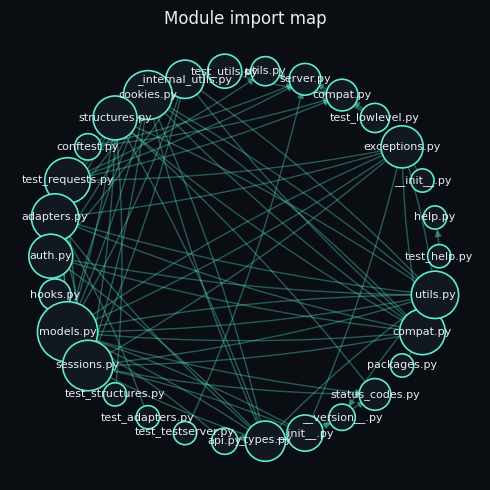

In [87]:

summary = analyze_and_show(
    repo_url=REPO_URL,
    model_name=MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    skip_ai_summary=SKIP_AI_SUMMARY,
)


In [88]:
#-----------UI-----------------
import ipywidgets as widgets

_repo_input = widgets.Text(value=REPO_URL, description="Repo URL:", layout=widgets.Layout(width="480px"))
_model_input = widgets.Text(value=MODEL_NAME, description="Model:", layout=widgets.Layout(width="320px"))
_skip_ai_input = widgets.Checkbox(value=SKIP_AI_SUMMARY, description="Structure only (skip local model)")
_run_button = widgets.Button(description="Analyze", button_style="success", icon="search")
_output = widgets.Output()

_last_summary = {"value": None}

def _on_click(_):
    with _output:
        _output.clear_output()
        try:
            result = analyze_and_show(
                repo_url=_repo_input.value.strip(),
                model_name=_model_input.value.strip(),
                max_new_tokens=MAX_NEW_TOKENS,
                skip_ai_summary=_skip_ai_input.value,
            )
            _last_summary["value"] = result
        except Exception as e:
            print(f"✕ {e}")

_run_button.on_click(_on_click)

display(widgets.VBox([_repo_input, _model_input, _skip_ai_input, _run_button, _output]))


In [89]:
# --- Export the summary as a downloadable HTML report --------------------

_summary_to_export = _last_summary["value"] if "_last_summary" in dir() and _last_summary.get("value") else globals().get("summary")

if _summary_to_export:
    report_path = export_html_report(_summary_to_export, "repo_report.html")
    print(f"Report saved to: {report_path}")
    display(FileLink(report_path))
else:
    print("Dint ran---re run it")


Report saved to: /content/repo_report.html


/content/repo_report.html